In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 


In [3]:
df = pd.read_csv("Data/cancer_dataset.csv")

# بخش اول 
# Data selection 

### سوال 1 

کدام ویژگی‌ها بیشترین ارتباط را با متغیر هدف (Level) دارند؟

In [4]:
df_corr = df.copy() 
df_corr["Level"] = df_corr["Level"].map({
    "Low": 0,
    "Medium": 1,
    "High": 2
})
correlation = df_corr.corr(numeric_only=True)["Level"].sort_values(ascending=False)

print(correlation)

Level                       1.000000
Obesity                     0.827435
Coughing of Blood           0.782092
Alcohol use                 0.718710
Dust Allergy                0.713839
Balanced Diet               0.706273
Passive Smoker              0.703594
Genetic Risk                0.701303
OccuPational Hazards        0.673255
Chest Pain                  0.645461
Air Pollution               0.636038
Fatigue                     0.625114
chronic Lung Disease        0.609971
Smoking                     0.519530
Shortness of Breath         0.497024
Frequent Cold               0.444017
Dry Cough                   0.373968
Weight Loss                 0.352738
Snoring                     0.289366
Clubbing of Finger Nails    0.280063
Swallowing Difficulty       0.249142
Wheezing                    0.242794
Age                         0.060048
index                       0.057758
Gender                     -0.164985
Name: Level, dtype: float64


ویژگی‌هایی که ضریب همبستگی بزرگ‌تری دارند، ارتباط بیشتری با متغیر هدف دارند.

### سوال 2

یک جدول تهیه کنید:

| Feature | Business Importance | Data Importance |
| ------- | ------------------- | --------------- |

| Feature              | Business Importance | Data Importance |
| -------------------- | ------------------- | --------------- |
| Smoking              | High                | High            |
| Air Pollution        | High                | High            |
| Genetic Risk         | High                | High            |
| Passive Smoker       | High                | High            |
| chronic Lung Disease | High                | High            |
| Coughing of Blood    | High                | High            |
| Shortness of Breath  | High                | Medium          |
| Chest Pain           | Medium              | Medium          |
| Obesity              | Medium              | Medium          |
| Alcohol use          | Medium              | Medium          |
| Dust Allergy         | Low                 | Low             |
| Balanced Diet        | Medium              | Low             |
| Frequent Cold        | Low                 | Low             |
| Dry Cough            | Medium              | Medium          |
| Snoring              | Low                 | Low             |
| Patient Id           | Low                 | Low             |


### سوال 3

حداقل سه ویژگی را که احتمال می‌دهید برای مدل‌سازی اهمیت کمتری دارند معرفی کنید و دلیل انتخاب خود را بنویسید.

patient id ->  فقط شناسه بیمار است و هیچ اطلاعاتی درباره خطر سرطان ریه ارائه نمی‌دهد؛ بنابراین در مدل‌سازی استفاده نمی‌شود.

snoring ->  ارتباط مستقیمی با سرطان ریه ندارد و معمولاً نسبت به ویژگی‌هایی مانند Smoking یا Air Pollution اهمیت کمتری دارد.

frequent cold ->  سرماخوردگی مکرر می‌تواند به دلایل مختلفی رخ دهد و به‌تنهایی شاخص مناسبی برای پیش‌بینی سرطان ریه نیست.  

### سوال 4

یک نسخه جدید از دیتاست ایجاد کنید که فقط شامل ویژگی‌های منتخب باشد.

In [5]:
selected_df = df.drop(columns=[
    "Patient Id",
    "Snoring",
    "Frequent Cold"
])

selected_df.head()

,index,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,Balanced Diet,...,Chest Pain,Coughing of Blood,Fatigue,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Dry Cough,Level
0,0,33,1,2,4,5,4,3,2,2,...,2,4,3,4,2,2,3,1,3,Low
1,1,17,1,3,1,5,3,4,2,2,...,2,3,1,3,7,8,6,2,7,Medium
2,2,35,1,4,5,6,5,5,4,6,...,4,8,8,7,9,2,1,4,7,High
3,3,37,1,7,7,7,7,6,7,7,...,7,8,4,2,3,1,4,5,7,High
4,4,46,1,6,8,7,7,7,6,7,...,7,9,3,2,4,1,4,2,2,High


### سوال 5


تعداد ویژگی‌ها را قبل و بعد از Data Selection مقایسه کنید.

In [6]:
print("Before:", df.shape)
print("After:", selected_df)

Before: (1000, 26)
After:      index  Age  Gender  Air Pollution  Alcohol use  Dust Allergy  \
0        0   33       1              2            4             5   
1        1   17       1              3            1             5   
2        2   35       1              4            5             6   
3        3   37       1              7            7             7   
4        4   46       1              6            8             7   
..     ...  ...     ...            ...          ...           ...   
995    995   44       1              6            7             7   
996    996   37       2              6            8             7   
997    997   25       2              4            5             6   
998    998   18       2              6            8             7   
999    999   47       1              6            5             6   

     OccuPational Hazards  Genetic Risk  chronic Lung Disease  Balanced Diet  \
0                       4             3                     2    

# بخش دوم
# Data cleaning

### سوال 6

بررسی کنید آیا داده گمشده وجود دارد.

In [7]:
selected_df = df.drop(columns=["Patient Id", "Snoring", "Frequent Cold"])

selected_df.isnull().sum()

index                       0
Age                         0
Gender                      0
Air Pollution               0
Alcohol use                 0
Dust Allergy                0
OccuPational Hazards        0
Genetic Risk                0
chronic Lung Disease        0
Balanced Diet               0
Obesity                     0
Smoking                     0
Passive Smoker              0
Chest Pain                  0
Coughing of Blood           0
Fatigue                     0
Weight Loss                 0
Shortness of Breath         0
Wheezing                    0
Swallowing Difficulty       0
Clubbing of Finger Nails    0
Dry Cough                   0
Level                       0
dtype: int64

داده گمشده وجود ندارد

### سوال 7

تعداد داده‌های تکراری را بررسی کنید.

در صورت وجود داده تکراری، آن‌ها را حذف کنید.

In [8]:
selected_df.duplicated().sum()

np.int64(0)

داده تکراری وجود ندارد

### سوال 8

وجود داده‌های پرت (Outlier) را بررسی کنید.

(Boxplot)

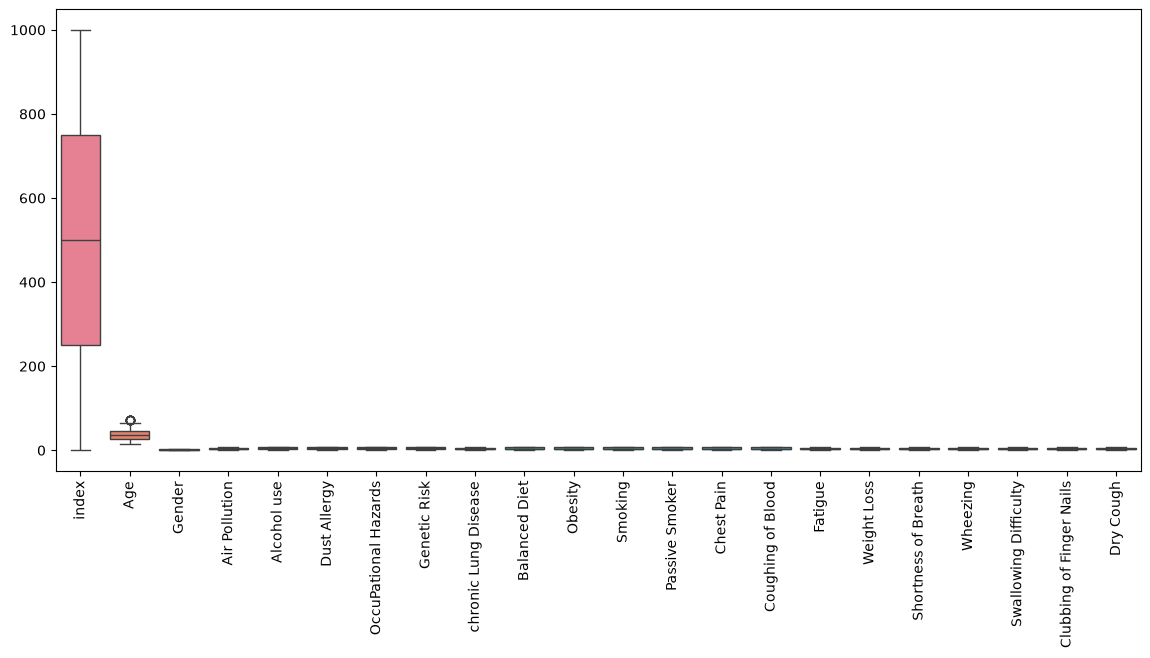

In [9]:
plt.figure(figsize=(14,6))
sns.boxplot(data=selected_df)
plt.xticks(rotation=90)
plt.show()

# بخش سوم
# Data construction

### سوال 9

سن را به ۳ گروه تقسیم کنید.

In [10]:
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[0, 30, 50, 100],
    labels=["Young", "Middle-aged", "Old"]
)

df[["Age", "Age_Group"]].head()

,Age,Age_Group
0,33,Middle-aged
1,17,Young
2,35,Middle-aged
3,37,Middle-aged
4,46,Middle-aged


In [11]:
df["Age_Group"].value_counts()

Age_Group
Middle-aged    565
Young          301
Old            134
Name: count, dtype: int64

که ۳ دسته است Age_Group در این مرحله یک ویژگی حدید اضافه شده 

Young -> کمتر از ۳۰

Middle_aged -> بین ۳۰ تا ۵۰

Old -> بیشتر از ۵۰

### سوال 10

سطح چاقی تعریف کنید. obesity  برای 

In [12]:
df["Obesity_Level"] = pd.cut(
    df["Obesity"],
    bins=[0, 2, 5, 7],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)
df[["Obesity", "Obesity_Level"]].head()

,Obesity,Obesity_Level
0,4,Medium
1,2,Low
2,7,High
3,7,High
4,7,High


In [13]:
df["Obesity_Level"].value_counts()

Obesity_Level
Medium    404
High      386
Low       210
Name: count, dtype: int64

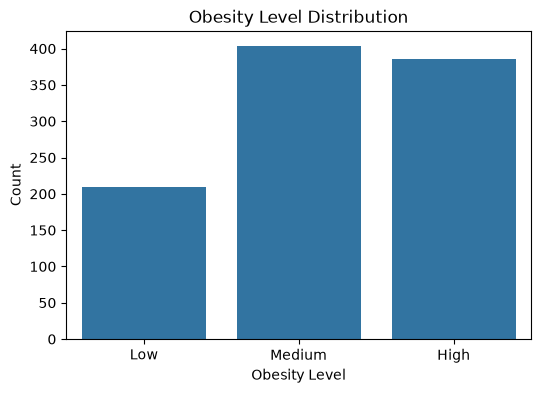

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Obesity_Level")

plt.title("Obesity Level Distribution")
plt.xlabel("Obesity Level")
plt.ylabel("Count")

plt.show()

### سوال 11

حداقل ۲ ویژگی جدید تعریف کنید و دلایل کسب و کاری آن را بنویسید.

In [20]:
df["Family History"] = np.random.choice([0, 1], size=len(df))

df[["Family History"]].head()

,Family History
0,1
1,0
2,0
3,1
4,1


مقدار ۰ یعنی سابقه خانوادگی ندارد و ۱ یعنی دارد. 

In [21]:
df["Exposure Duration"] = np.random.randint(1, 31, size=len(df))

df[["Exposure Duration"]].head()

,Exposure Duration
0,20
1,17
2,3
3,1
4,17


این ویژگی مدت قرار گرقتن در معرض خطر را بررسی میکند مثلا آلودگی هوا یا دود سیگار بر حسب سال

### سوال 12

جدول زیر را تکمیل کنید

| New Feature | Business Reason |

| New Feature           | Business Reason                                                                                                                                                                                                                     |
| --------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Family History**    | سابقه خانوادگی سرطان ریه یکی از عوامل مهم خطر است. اضافه کردن این ویژگی به مدل می‌تواند نقش عوامل ژنتیکی و وراثتی را در پیش‌بینی سطح سرطان (**Level**) بهتر نشان دهد.                                                               |
| **Exposure Duration** | مدت زمان قرار گرفتن در معرض عوامل خطر مانند دود سیگار، آلودگی هوا یا مواد شیمیایی می‌تواند بر احتمال ابتلا و شدت سرطان ریه تأثیر بگذارد. این ویژگی به مدل کمک می‌کند تا علاوه بر شدت مواجهه، اثر طولانی‌مدت آن را نیز در نظر بگیرد. |


# بخش چهارم
# Data integration

### سوال 13

یک DataFrame آزمایشی از اطلاعات تکمیلی بیماران ایجاد کنید.

In [22]:
lab_results = pd.DataFrame({
    "Patient Id": ["P1", "P2", "P3", "P4", "P5"],
    "Blood Oxygen": [96, 92, 88, 95, 90],
    "Lung Capacity": [85, 70, 60, 82, 68]
})

lab_results

,Patient Id,Blood Oxygen,Lung Capacity
0,P1,96,85
1,P2,92,70
2,P3,88,60
3,P4,95,82
4,P5,90,68


### سوال 14

یک کلید مشترک بین دیتاست اصلی و DataFrame جدید تعریف کنید.

کلید مشترک برای ادغام دو جدول، ستون Patient Id است؛ زیرا در هر دو جدول شناسه هر بیمار را مشخص می‌کند.

### سوال 15

دو جدول را با استفاده از ستون Patient Id با یکدیگر ادغام (Merge) کنید.

In [23]:
merged_df = pd.merge(
    df,
    lab_results,
    on="Patient Id",
    how="inner"
)

merged_df.head()

,index,Patient Id,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,...,Dry Cough,Snoring,Level,Age_Group,Obesity_Level,Pollution Level,Family History,Exposure Duration,Blood Oxygen,Lung Capacity
0,0,P1,33,1,2,4,5,4,3,2,...,3,4,Low,Middle-aged,Medium,Low,1,20,96,85
1,112,P2,25,2,3,1,4,3,2,3,...,4,3,Low,Young,Medium,Low,1,18,92,70
2,223,P3,35,1,4,5,6,5,6,5,...,4,1,Medium,Middle-aged,Medium,Medium,0,22,88,60
3,334,P4,27,1,2,3,4,2,4,3,...,1,5,Medium,Young,Medium,Low,1,14,95,82
4,445,P5,48,1,6,7,7,7,7,6,...,5,3,High,Middle-aged,High,Medium,1,3,90,68


### سوال 16

انواع Merge زیر را با هم مقایسه کنید.

In [ ]:
pd.merge(df, lab_results, on="Patient Id", how="inner")

,index,Patient Id,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,...,Dry Cough,Snoring,Level,Age_Group,Obesity_Level,Pollution Level,Family History,Exposure Duration,Blood Oxygen,Lung Capacity
0,0,P1,33,1,2,4,5,4,3,2,...,3,4,Low,Middle-aged,Medium,Low,1,20,96,85
1,112,P2,25,2,3,1,4,3,2,3,...,4,3,Low,Young,Medium,Low,1,18,92,70
2,223,P3,35,1,4,5,6,5,6,5,...,4,1,Medium,Middle-aged,Medium,Medium,0,22,88,60
3,334,P4,27,1,2,3,4,2,4,3,...,1,5,Medium,Young,Medium,Low,1,14,95,82
4,445,P5,48,1,6,7,7,7,7,6,...,5,3,High,Middle-aged,High,Medium,1,3,90,68


In [ ]:
pd.merge(df, lab_results, on="Patient Id", how="left")

,index,Patient Id,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,...,Dry Cough,Snoring,Level,Age_Group,Obesity_Level,Pollution Level,Family History,Exposure Duration,Blood Oxygen,Lung Capacity
0,0,P1,33,1,2,4,5,4,3,2,...,3,4,Low,Middle-aged,Medium,Low,1,20,96.0,85.0
1,1,P10,17,1,3,1,5,3,4,2,...,7,2,Medium,Young,Low,Low,0,17,NaN,NaN
2,2,P100,35,1,4,5,6,5,5,4,...,7,2,High,Middle-aged,High,Medium,0,3,NaN,NaN
3,3,P1000,37,1,7,7,7,7,6,7,...,7,5,High,Middle-aged,High,High,1,1,NaN,NaN
4,4,P101,46,1,6,8,7,7,7,6,...,2,3,High,Middle-aged,High,Medium,1,17,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,995,P995,44,1,6,7,7,7,7,6,...,5,3,High,Middle-aged,High,Medium,0,6,NaN,NaN
996,996,P996,37,2,6,8,7,7,7,6,...,1,4,High,Middle-aged,High,Medium,0,29,NaN,NaN
997,997,P997,25,2,4,5,6,5,5,4,...,7,2,High,Young,High,Medium,0,13,NaN,NaN
998,998,P998,18,2,6,8,7,7,7,6,...,2,3,High,Young,High,Medium,0,7,NaN,NaN


In [ ]:
pd.merge(df, lab_results, on="Patient Id", how="right")

,index,Patient Id,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,...,Dry Cough,Snoring,Level,Age_Group,Obesity_Level,Pollution Level,Family History,Exposure Duration,Blood Oxygen,Lung Capacity
0,0,P1,33,1,2,4,5,4,3,2,...,3,4,Low,Middle-aged,Medium,Low,1,20,96,85
1,112,P2,25,2,3,1,4,3,2,3,...,4,3,Low,Young,Medium,Low,1,18,92,70
2,223,P3,35,1,4,5,6,5,6,5,...,4,1,Medium,Middle-aged,Medium,Medium,0,22,88,60
3,334,P4,27,1,2,3,4,2,4,3,...,1,5,Medium,Young,Medium,Low,1,14,95,82
4,445,P5,48,1,6,7,7,7,7,6,...,5,3,High,Middle-aged,High,Medium,1,3,90,68


In [27]:
pd.merge(df, lab_results, on="Patient Id", how="outer")

,index,Patient Id,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,...,Dry Cough,Snoring,Level,Age_Group,Obesity_Level,Pollution Level,Family History,Exposure Duration,Blood Oxygen,Lung Capacity
0,0,P1,33,1,2,4,5,4,3,2,...,3,4,Low,Middle-aged,Medium,Low,1,20,96.0,85.0
1,1,P10,17,1,3,1,5,3,4,2,...,7,2,Medium,Young,Low,Low,0,17,NaN,NaN
2,2,P100,35,1,4,5,6,5,5,4,...,7,2,High,Middle-aged,High,Medium,0,3,NaN,NaN
3,3,P1000,37,1,7,7,7,7,6,7,...,7,5,High,Middle-aged,High,High,1,1,NaN,NaN
4,4,P101,46,1,6,8,7,7,7,6,...,2,3,High,Middle-aged,High,Medium,1,17,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,995,P995,44,1,6,7,7,7,7,6,...,5,3,High,Middle-aged,High,Medium,0,6,NaN,NaN
996,996,P996,37,2,6,8,7,7,7,6,...,1,4,High,Middle-aged,High,Medium,0,29,NaN,NaN
997,997,P997,25,2,4,5,6,5,5,4,...,7,2,High,Young,High,Medium,0,13,NaN,NaN
998,998,P998,18,2,6,8,7,7,7,6,...,2,3,High,Young,High,Medium,0,7,NaN,NaN


| نوع Merge       | توضیح                                                                                         |
| --------------- | --------------------------------------------------------------------------------------------- |
| **Inner Merge** | فقط رکوردهایی را نگه می‌دارد که در هر دو جدول کلید مشترک دارند.                               |
| **Left Merge**  | تمام رکوردهای جدول اصلی را نگه می‌دارد و اطلاعات جدول دوم را در صورت وجود اضافه می‌کند.       |
| **Right Merge** | تمام رکوردهای جدول دوم را نگه می‌دارد و اطلاعات جدول اول را در صورت وجود اضافه می‌کند.        |
| **Outer Merge** | تمام رکوردهای هر دو جدول را نگه می‌دارد و در صورت نبود مقدار متناظر، مقدار `NaN` قرار می‌دهد. |


### سوال 17

مشخص کنید برای این پروژه کدام نوع Merge مناسب‌تر است.

In [28]:
merged_df = pd.merge(
    df,
    lab_results,
    on="Patient Id",
    how="left"
)

merged_df.head()

,index,Patient Id,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,...,Dry Cough,Snoring,Level,Age_Group,Obesity_Level,Pollution Level,Family History,Exposure Duration,Blood Oxygen,Lung Capacity
0,0,P1,33,1,2,4,5,4,3,2,...,3,4,Low,Middle-aged,Medium,Low,1,20,96.0,85.0
1,1,P10,17,1,3,1,5,3,4,2,...,7,2,Medium,Young,Low,Low,0,17,NaN,NaN
2,2,P100,35,1,4,5,6,5,5,4,...,7,2,High,Middle-aged,High,Medium,0,3,NaN,NaN
3,3,P1000,37,1,7,7,7,7,6,7,...,7,5,High,Middle-aged,High,High,1,1,NaN,NaN
4,4,P101,46,1,6,8,7,7,7,6,...,2,3,High,Middle-aged,High,Medium,1,17,NaN,NaN


Left Merge مناسب‌ترین روش برای این پروژه است؛ زیرا هدف این است که تمام بیماران موجود در دیتاست اصلی حفظ شوند و در صورت وجود اطلاعات تکمیلی (مانند نتایج آزمایش یا اطلاعات پزشکی دیگر)، آن اطلاعات به رکوردهای مربوطه اضافه شوند.

# بخش پنجم
# Data Formatting

### سوال 18

نوع داده (Data Type) تمام ستون‌های دیتاست را بررسی کنید.

In [31]:
df.dtypes

index                          int64
Patient Id                       str
Age                            int64
Gender                         int64
Air Pollution                  int64
Alcohol use                    int64
Dust Allergy                   int64
OccuPational Hazards           int64
Genetic Risk                   int64
chronic Lung Disease           int64
Balanced Diet                  int64
Obesity                        int64
Smoking                        int64
Passive Smoker                 int64
Chest Pain                     int64
Coughing of Blood              int64
Fatigue                        int64
Weight Loss                    int64
Shortness of Breath            int64
Wheezing                       int64
Swallowing Difficulty          int64
Clubbing of Finger Nails       int64
Frequent Cold                  int64
Dry Cough                      int64
Snoring                        int64
Level                            str
Age_Group                   category
O

### سوال 19

ستون‌هایی را که باید به نوع Category تبدیل شوند، شناسایی کنید.

به نوع دسته ای تبدیل شوند.
  Level  , Gender در این دیتاست بهنر است ستون های 

### سوال 20

نوع داده مناسب را برای ستون‌های دسته‌ای اعمال کنید.


In [33]:
df["Gender"] = df["Gender"].astype("category")
df["Level"] = df["Level"].astype("category")

df.dtypes

index                          int64
Patient Id                       str
Age                            int64
Gender                      category
Air Pollution                  int64
Alcohol use                    int64
Dust Allergy                   int64
OccuPational Hazards           int64
Genetic Risk                   int64
chronic Lung Disease           int64
Balanced Diet                  int64
Obesity                        int64
Smoking                        int64
Passive Smoker                 int64
Chest Pain                     int64
Coughing of Blood              int64
Fatigue                        int64
Weight Loss                    int64
Shortness of Breath            int64
Wheezing                       int64
Swallowing Difficulty          int64
Clubbing of Finger Nails       int64
Frequent Cold                  int64
Dry Cough                      int64
Snoring                        int64
Level                       category
Age_Group                   category
O

### سوال 21 

حجم حافظه قبل و بعد از تغییر نوع داده‌ها را مقایسه کنید.

In [34]:
df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   index                     1000 non-null   int64   
 1   Patient Id                1000 non-null   str     
 2   Age                       1000 non-null   int64   
 3   Gender                    1000 non-null   category
 4   Air Pollution             1000 non-null   int64   
 5   Alcohol use               1000 non-null   int64   
 6   Dust Allergy              1000 non-null   int64   
 7   OccuPational Hazards      1000 non-null   int64   
 8   Genetic Risk              1000 non-null   int64   
 9   chronic Lung Disease      1000 non-null   int64   
 10  Balanced Diet             1000 non-null   int64   
 11  Obesity                   1000 non-null   int64   
 12  Smoking                   1000 non-null   int64   
 13  Passive Smoker            1000 non-null   int64   
 14  Ches

In [35]:
df["Gender"] = df["Gender"].astype("category")
df["Level"] = df["Level"].astype("category")

df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   index                     1000 non-null   int64   
 1   Patient Id                1000 non-null   str     
 2   Age                       1000 non-null   int64   
 3   Gender                    1000 non-null   category
 4   Air Pollution             1000 non-null   int64   
 5   Alcohol use               1000 non-null   int64   
 6   Dust Allergy              1000 non-null   int64   
 7   OccuPational Hazards      1000 non-null   int64   
 8   Genetic Risk              1000 non-null   int64   
 9   chronic Lung Disease      1000 non-null   int64   
 10  Balanced Diet             1000 non-null   int64   
 11  Obesity                   1000 non-null   int64   
 12  Smoking                   1000 non-null   int64   
 13  Passive Smoker            1000 non-null   int64   
 14  Ches

با تبدیل ستون‌های متنی به نوع category، مصرف حافظه کاهش می‌یابد و پردازش داده‌ها در بسیاری از عملیات سریع‌تر می‌شود.